In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('indian_bike_sales.csv')
print('Shape:', df.shape) # Should show (10000, 15)
print(df.head())
print(df.info())
print(df.isnull().sum()) # Check for missing values
print(df.describe()) # Summary statistics

Shape: (10000, 15)
            State  Avg Daily Distance (km)          Brand        Model  \
0       Karnataka                    68.84  Royal Enfield   Hunter 350   
1       Rajasthan                    23.80          Bajaj  Dominar 400   
2  Madhya Pradesh                    27.67            KTM     125 Duke   
3       Karnataka                    62.85       Kawasaki    Ninja 300   
4  Madhya Pradesh                    10.62         Yamaha        FZ V3   

   Price (INR)  Year of Manufacture  Engine Capacity (cc) Fuel Type  \
0       252816                 2021                   672  Electric   
1       131100                 2020                   769    Hybrid   
2       201016                 2020                   216    Hybrid   
3       132482                 2021                   556    Petrol   
4       231796                 2019                   298    Petrol   

   Mileage (km/l) Owner Type  Registration Year Insurance Status Seller Type  \
0           78.41     Second 

In [2]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)
# Ensure numeric types are correct
df['Price (INR)'] = pd.to_numeric(df['Price (INR)'], errors='coerce')
df['Resale Price (INR)'] = pd.to_numeric(df['Resale Price (INR)'], errors='coerce')
df['Mileage (km/l)'] = pd.to_numeric(df['Mileage (km/l)'], errors='coerce')
df['Engine Capacity (cc)'] = pd.to_numeric(df['Engine Capacity (cc)'], errors='coerce')
# Add calculated columns
df['Depreciation (INR)'] = df['Price (INR)'] - df['Resale Price (INR)']
df['Depreciation %'] = (df['Depreciation (INR)'] / df['Price (INR)']) * 100
df['Bike Age (Years)'] = df['Registration Year'] - df['Year of Manufacture']
# Save cleaned dataset
df.to_csv('cleaned_bike_sales.csv', index=False)
print('Cleaned shape:', df.shape)
print('New columns:', df.columns.tolist())

Cleaned shape: (10000, 18)
New columns: ['State', 'Avg Daily Distance (km)', 'Brand', 'Model', 'Price (INR)', 'Year of Manufacture', 'Engine Capacity (cc)', 'Fuel Type', 'Mileage (km/l)', 'Owner Type', 'Registration Year', 'Insurance Status', 'Seller Type', 'Resale Price (INR)', 'City Tier', 'Depreciation (INR)', 'Depreciation %', 'Bike Age (Years)']


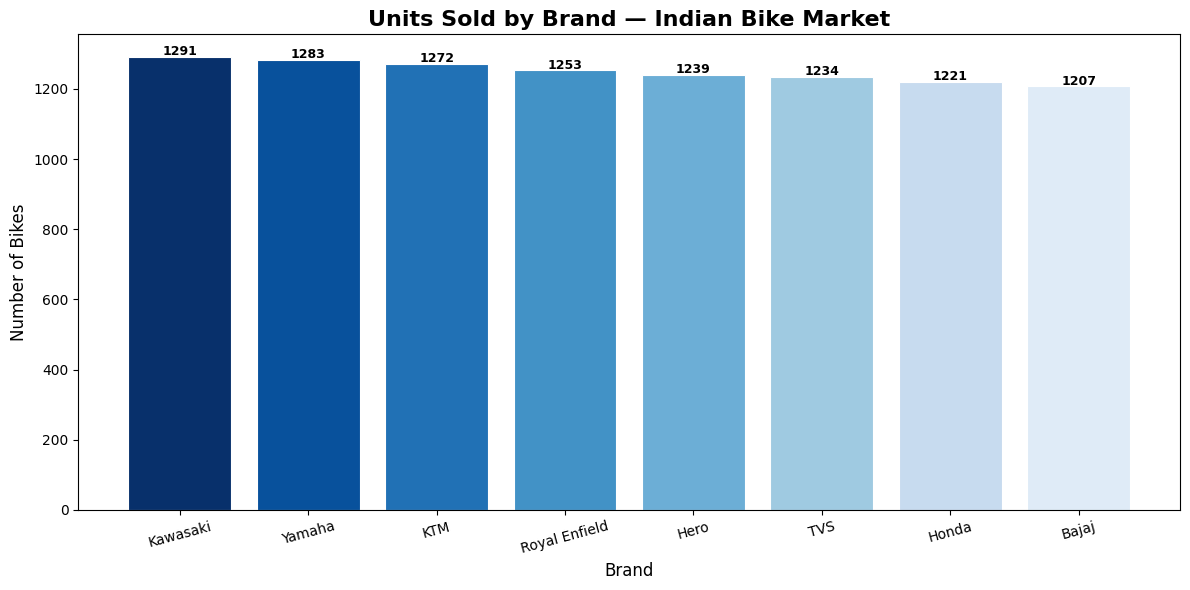

In [5]:
import os
import matplotlib.pyplot as plt

# Count the brands
brand_counts = df['Brand'].value_counts()

# Create the figure
plt.figure(figsize=(12, 6))

# Draw bars
bars = plt.bar(
    brand_counts.index,
    brand_counts.values,
    color=plt.cm.Blues_r([i/8 for i in range(len(brand_counts))]),
    edgecolor='white',
    linewidth=0.8
)

# Titles and labels
plt.title('Units Sold by Brand — Indian Bike Market', fontsize=16, fontweight='bold')
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Number of Bikes', fontsize=12)
plt.xticks(rotation=15)

# Add value labels above bars
for bar, val in zip(bars, brand_counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        str(val),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()

# Ensure charts folder exists
os.makedirs('charts', exist_ok=True)

# Save the chart
plt.savefig('charts/chart1_brand_distribution.png', dpi=150)
plt.show()


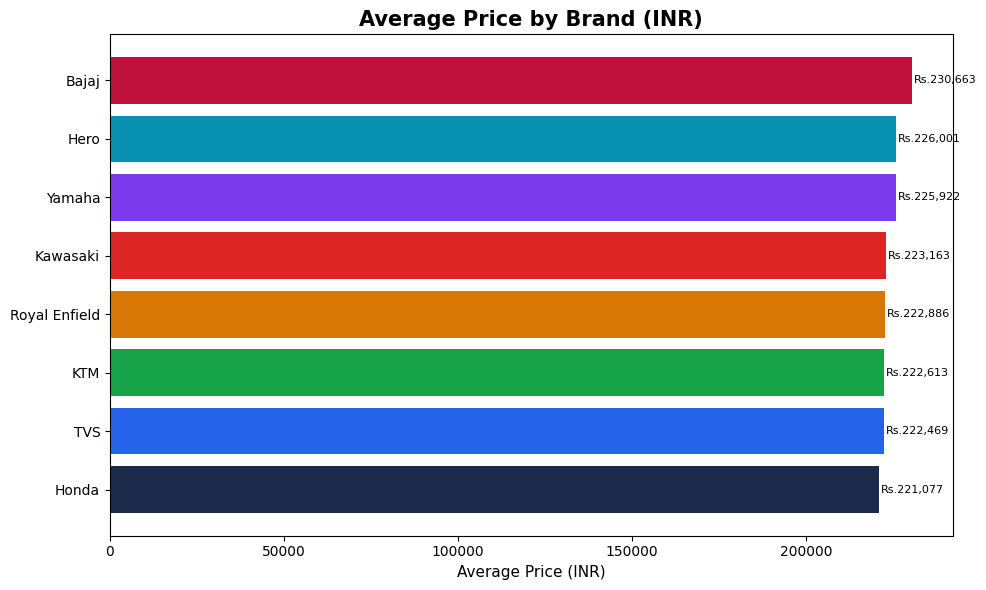

In [8]:
import os
import matplotlib.pyplot as plt

# Calculate average price per brand
avg_price = df.groupby('Brand')['Price (INR)'].mean().sort_values(ascending=True)

plt.figure(figsize=(10, 6))

# Define colors
colors_list = ['#1B2A4A','#2563EB','#16A34A','#D97706',
               '#DC2626','#7C3AED','#0891B2','#BE123C']

# Horizontal bar chart
bars = plt.barh(avg_price.index, avg_price.values, color=colors_list)

# Titles and labels
plt.title('Average Price by Brand (INR)', fontsize=15, fontweight='bold')
plt.xlabel('Average Price (INR)', fontsize=11)

# Add value labels
for bar, val in zip(bars, avg_price.values):
    plt.text(
        val + 500,  # offset so text is outside the bar
        bar.get_y() + bar.get_height()/2,
        f'Rs.{val:,.0f}',
        va='center',
        fontsize=8
    )

plt.tight_layout()

# Ensure charts folder exists
os.makedirs('charts', exist_ok=True)

# Save chart
plt.savefig('charts/chart2_avg_price_brand.png', dpi=150)
plt.show()


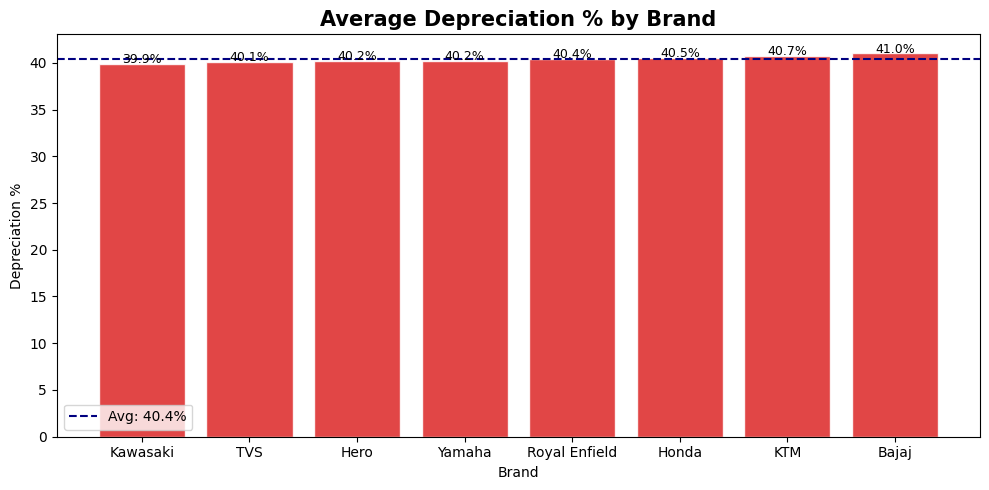

In [10]:
import os
import matplotlib.pyplot as plt

# Calculate average depreciation per brand
dep = df.groupby('Brand')['Depreciation %'].mean().sort_values()

plt.figure(figsize=(10, 5))

# Bar chart
bars = plt.bar(
    dep.index,
    dep.values,
    color='#DC2626',
    alpha=0.85,
    edgecolor='white'
)

# Add average line
plt.axhline(
    dep.mean(),
    color='navy',
    linestyle='--',
    lw=1.5,
    label=f'Avg: {dep.mean():.1f}%'
)

# Titles and labels
plt.title('Average Depreciation % by Brand', fontsize=15, fontweight='bold')
plt.xlabel('Brand')
plt.ylabel('Depreciation %')
plt.legend()

# Add value labels above bars
for bar, val in zip(bars, dep.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f'{val:.1f}%',
        ha='center',
        fontsize=9
    )

plt.tight_layout()

# Ensure charts folder exists
os.makedirs('charts', exist_ok=True)

# Save chart
plt.savefig('charts/chart3_depreciation_brand.png', dpi=150)
plt.show()


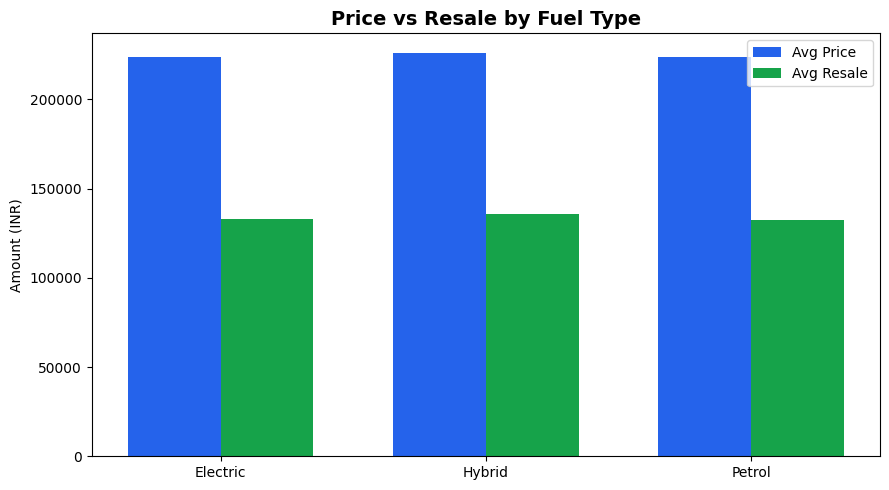

In [11]:
import os
import matplotlib.pyplot as plt

# Calculate average price and resale by fuel type
fuel_dep = df.groupby('Fuel Type').agg(
    Avg_Price=('Price (INR)', 'mean'),
    Avg_Resale=('Resale Price (INR)', 'mean')
).reset_index()

x = range(len(fuel_dep))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

# Bars for Avg Price and Avg Resale
ax.bar([i - width/2 for i in x], fuel_dep['Avg_Price'],
       width, label='Avg Price', color='#2563EB')
ax.bar([i + width/2 for i in x], fuel_dep['Avg_Resale'],
       width, label='Avg Resale', color='#16A34A')

# X-axis labels
ax.set_xticks(list(x))
ax.set_xticklabels(fuel_dep['Fuel Type'])

# Titles and labels
ax.set_ylabel('Amount (INR)')
ax.set_title('Price vs Resale by Fuel Type', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()

# Ensure charts folder exists
os.makedirs('charts', exist_ok=True)

# Save chart
plt.savefig('charts/chart4_fuel_price_resale.png', dpi=150)
plt.show()


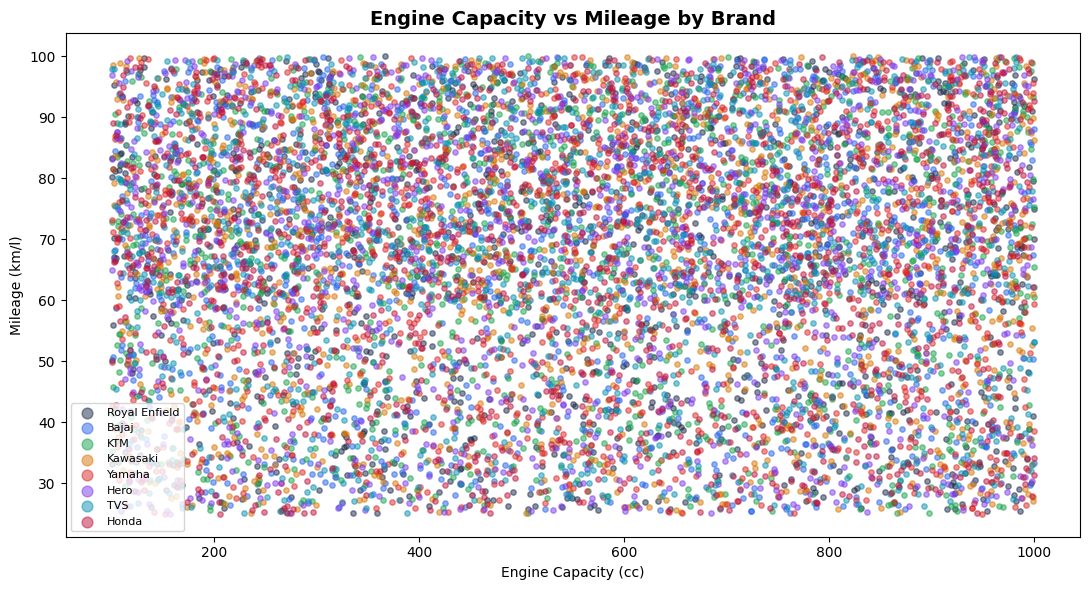

In [12]:
import os
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

brands = df['Brand'].unique()
palette = ['#1B2A4A','#2563EB','#16A34A','#D97706',
           '#DC2626','#7C3AED','#0891B2','#BE123C']

# Scatter plot for each brand
for brand, color in zip(brands, palette):
    subset = df[df['Brand'] == brand]
    plt.scatter(
        subset['Engine Capacity (cc)'],
        subset['Mileage (km/l)'],
        label=brand,
        alpha=0.5,
        s=15,
        color=color
    )

# Titles and labels
plt.title('Engine Capacity vs Mileage by Brand', fontsize=14, fontweight='bold')
plt.xlabel('Engine Capacity (cc)')
plt.ylabel('Mileage (km/l)')
plt.legend(markerscale=2, fontsize=8)

plt.tight_layout()

# Ensure charts folder exists
os.makedirs('charts', exist_ok=True)

# Save chart
plt.savefig('charts/chart5_engine_vs_mileage.png', dpi=150)
plt.show()


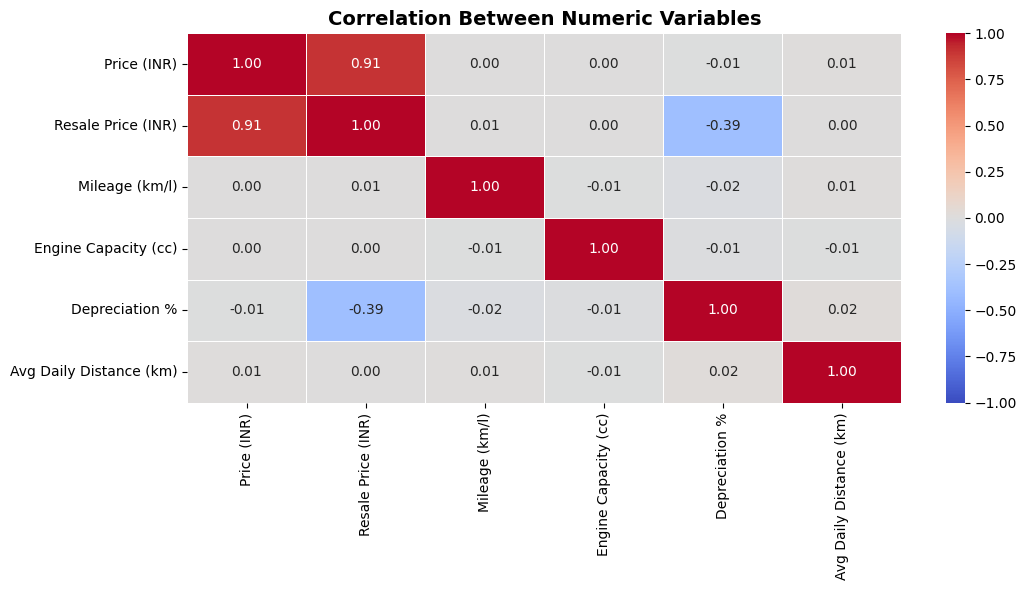

In [13]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11, 6))

# Select numeric columns and drop missing values
num_cols = df[['Price (INR)', 'Resale Price (INR)', 'Mileage (km/l)',
               'Engine Capacity (cc)', 'Depreciation %',
               'Avg Daily Distance (km)']].dropna()

# Heatmap of correlations
sns.heatmap(
    num_cols.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title('Correlation Between Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()

# Ensure charts folder exists
os.makedirs('charts', exist_ok=True)

# Save chart
plt.savefig('charts/chart6_correlation_heatmap.png', dpi=150)
plt.show()



In [14]:
from scipy import stats

# Split data by seller type
dealer = df[df['Seller Type'] == 'Dealer']['Price (INR)'].dropna()
individual = df[df['Seller Type'] == 'Individual']['Price (INR)'].dropna()

# Perform t-test
t_stat, p_value = stats.ttest_ind(dealer, individual)

# Print summary
print(f'Dealer avg price: Rs.{dealer.mean():,.0f}')
print(f'Individual avg price: Rs.{individual.mean():,.0f}')
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_value:.4f}')

# Decision rule
if p_value < 0.05:
    print('RESULT: Significant price difference between Dealer & Individual!')
else:
    print('RESULT: No statistically significant price difference')


Dealer avg price: Rs.225,281
Individual avg price: Rs.223,363
T-statistic: 0.9514
P-value: 0.3414
RESULT: No statistically significant price difference
